In [1]:
%env OMP_NUM_THREADS=1
%env OPENBLAS_NUM_THREADS=1
%env MKL_NUM_THREADS=1

env: OMP_NUM_THREADS=1
env: OPENBLAS_NUM_THREADS=1
env: MKL_NUM_THREADS=1


Register MALDI to H&E
Registration successful!


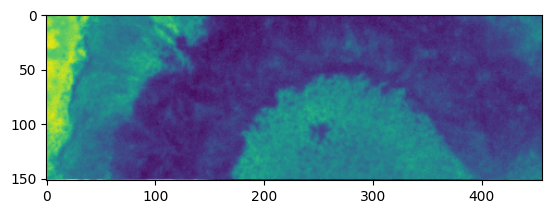

In [5]:
import yaml
import argparse
import os
import numpy as np

from pathlib import Path
import matplotlib.pyplot as plt


from preprocessing.he.crop_he import read_he
from preprocessing.maldi.read_imzml import read_imzml_only_peaks
from preprocessing.raman.crop_raman import crop_raman
from preprocessing.raman.run_ashlar_after_basic import run_ashlar
from preprocessing.raman.baseline_correction import remove_baseline_raman
from preprocessing.raman.smoothing import smooth_sample
from registration.register_maldi_to_he import register_maldi_to_he
from registration.register_raman_to_he import register_raman_to_he

DO_RAMAN = False

if __name__ == '__main__':
    
    os.environ["OMP_NUM_THREADS"] = "1"
    os.environ["MKL_NUM_THREADS"] = "1"
    os.environ["OPENBLAS_NUM_THREADS"] = "1"
    
    config_file = '/home/luna.kuleuven.be/u0172804/raman-maldi/configs/config_jelle.yaml'
    registration = True
    
    with open(config_file, 'r') as f:
        config = yaml.safe_load(f)
        path = os.path.expandvars(config['path'])
        sample = config['sample']
        run_basic = config['run_BaSiC']
        p_poly = config['p_poly']
        iterations_raman_cropping = config['iterations_raman_cropping']
        
    he_physical_size_x = he_physical_size_y = msi_physical_size_x = msi_physical_size_y = raman_physical_size_x = raman_physical_size_y = None
    
    if not registration:
        print('Cropping H&E image')
        he_physical_size_x, he_physical_size_y = read_he(f'{path}/{sample}/h&e/')
        print(f'Physical size H&E pixel: ({he_physical_size_x} μm, {he_physical_size_y} μm)')
        
        print('Converting .imzML file to .npy')
        dtype = np.float32
        msi_physical_size_x, msi_physical_size_y = read_imzml_only_peaks(f'{path}/{sample}/maldi/', dtype)
        print(f'Physical size MSI pixel: ({msi_physical_size_x} μm, {msi_physical_size_y} μm)')
        
        if DO_RAMAN == True:
            # raman preprocessing    
            print('Running ASHLAR')
            # run ashlar
            raman_physical_size_x, raman_physical_size_y = run_ashlar(f'{path}/{sample}/raman/')
            print(f'Physical size Raman pixel: ({raman_physical_size_x} μm, {raman_physical_size_y} μm)')
            
            crop_raman(f'{path}/{sample}/raman/ashlar.npy', iterations=iterations_raman_cropping)
            
            print('Raman: baseline correction')
            remove_baseline_raman(f'{path}/{sample}/raman/', 'ashlar_crop.npy', p_poly=p_poly)
            
            print('Raman: smoothing')
            smooth_sample(f'{path}/{sample}/raman/baseline_corrected_{p_poly}.npy', w=9, p=2)
    
    # registration
    print('Register MALDI to H&E')
    he_physical_size_x, he_physical_size_y = (1.0, 1.0)
    msi_physical_size_x, msi_physical_size_y = (20.0, 20.0)
    i = register_maldi_to_he(path, sample, (he_physical_size_x, he_physical_size_y), (msi_physical_size_x, msi_physical_size_y))
    
    # Rotate the image
    i = np.rot90(i, k=1)

    # Show i
    plt.imshow(i)

    try:
        register_maldi_to_he(path, sample, (he_physical_size_x, he_physical_size_y), (msi_physical_size_x, msi_physical_size_y))
        print('Registration successful!')
    except:
        pass
    
    if DO_RAMAN == True:
        data_path = f'{path}/{sample}/raman/ashlar_crop.npy'
        print('Register RAMAN to H&E')
        try:
            register_raman_to_he(path, sample, data_path, (he_physical_size_x, he_physical_size_y), (raman_physical_size_x, raman_physical_size_y))
            print('Registration successful!')
        except:
            pass
    
